In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Unemployment.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
df.columns = [c.strip() for c in df.columns]
df.rename(columns={
    "Region": "Shteti",
    "Estimated Unemployment Rate (%)": "UNEMPLOYMENT"
}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")
df.head()

,Shteti,Date,Frequency,UNEMPLOYMENT,Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:
df["UNEMPLOYMENT"].describe()[["mean", "min", "max"]]

mean    12.236929
min      0.500000
max     75.850000
Name: UNEMPLOYMENT, dtype: float64

In [6]:
para_covid = df[df["Date"] < "2020-04-01"]["UNEMPLOYMENT"].mean()
gjate_covid = df[df["Date"] >= "2020-04-01"]["UNEMPLOYMENT"].mean()
print(f"Para COVID-19: {para_covid:.2f}%")
print(f"Gjatë COVID-19: {gjate_covid:.2f}%")

Para COVID-19: 9.76%
Gjatë COVID-19: 13.28%


In [7]:
top5 = df.groupby("Shteti")["UNEMPLOYMENT"].mean().sort_values(ascending=False).head(5)
top5

Shteti
Haryana      27.477
Tripura      25.055
Jharkhand    19.539
Bihar        19.471
Delhi        18.414
Name: UNEMPLOYMENT, dtype: float64

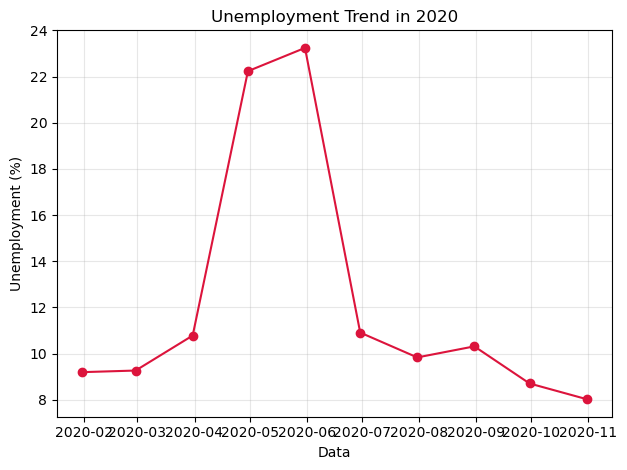

In [10]:
trendi = df.groupby("Date")["UNEMPLOYMENT"].mean()
plt.plot(trendi.index, trendi.values, marker="o", color="crimson")
plt.title("Unemployment Trend in 2020")
plt.xlabel("Data")
plt.ylabel("Unemployment (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
print("- Unemployment increased significantly during COVID-19.")
print(f"- The most affected country: {top5.index[0]}")
print("- Findings could help economic support policies.")

- Unemployment increased significantly during COVID-19.
- The most affected country: Haryana
- Findings could help economic support policies.
